In [70]:
import pandas as pd
import requests
import aiobotocore.session
import s3fs
import json
import os
import random

from datasets import Dataset, DatasetDict, load_from_disk, load_dataset
from requests.auth import HTTPBasicAuth
from IPython.display import JSON

/mnt/efs/mehermankikar/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [69]:
USER_ID = '65b91e6cf11e85c6770bc712'
basic = HTTPBasicAuth(USER_ID, '')
HOST = "https://ml-orchestration.ml-internal.scale.com"

In [70]:
def get_s3fs():
    s3_session = aiobotocore.session.AioSession(profile="ml-worker")
    storage_options = {"session": s3_session}
    fs = s3fs.S3FileSystem(**storage_options)
    return fs
def save_ds_s3(ds, path: str):
    fs = get_s3fs()
    ds.save_to_disk(path, storage_options=fs.storage_options)
def load_ds_s3(path: str):
    fs = get_s3fs()
    dataset = load_from_disk(path, storage_options=fs.storage_options)
    return dataset

In [71]:
import json

file_path = '/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/few_shot_examples/Coding_mt_en-US_530-2564_20240513.json'

with open(file_path, 'r') as f:
    data = json.load(f)

# Now you can work with the data from the JSON file
# Have 13 python 17 not. 
data = data[31:]
# Find 17 more python, 13 not. 
python_ex = 10
not_python_ex = 13
idxs_not_ise = [i for i in range(0,46)] + [51, 50, 55, 67, 71,72, 82, 85, 94, 115, 120, 121, 136, 139]
for idx, ex in enumerate(data):
    print(ex['metadata'].keys())
    if ex['metadata']['coding_language'].lower() == 'python' and python_ex > 0 and idx not in idxs_not_ise:
        # save the example as a json doc. 
        print("saved a python", python_ex)
        with open(f"/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/few_shot_examples/ots_examples_used/ots_nuggets_{idx+31}_python.json", "w") as f:
            json.dump([ex], f)
        python_ex -= 1
    elif not_python_ex > 0 and idx not in idxs_not_ise:
        print("saved a non python", not_python_ex)
        not_python_ex -= 1
        with open(f"/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/few_shot_examples/ots_examples_used/ots_nuggets_{idx+30}.json", "w") as f:
            json.dump([ex], f)
    # break
    if python_ex == 0 and not_python_ex == 0:
        break
print("left", python_ex, not_python_ex)

dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategory', 'coding_language', 'metrics'])
dict_keys(['category', 'subcategor

# Save json results to csv to plot

In [74]:
import json
import csv
with open('/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/ots_example_reruns_0810/llama-3-instruct-post-processed-new/llama-3-instr-results_processed.json', 'r') as f:
    data = json.load(f)

with open('/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/ots_example_reruns_0810/llama-3-instruct-post-processed-new/llama-3-instr-results_processed.csv', 'w', newline='') as csvfile:
    fieldnames = ['One Shot Example Used', 'Pass@1', 'Net New Passes', 'Net New Fails']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    
    for ex in data:
        pass1, _, _, new_right, new_wrong= data[ex]
        pass1 = pass1['pass@1']
        
        writer.writerow({'One Shot Example Used': ex, 'Pass@1': pass1, 'Net New Passes': new_right, 'Net New Fails': new_wrong})

## Make final plots for synthetic/ots coding data

In [73]:
import pandas as pd

file_path = '/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/final_report_plots/ots-code-llama-instruct-results.csv'
code_llama_good_ex = pd.read_csv(file_path, header=0)
# file_path = '/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/final_report_plots/code_llama_synthetic_bad_ex.csv'
# code_llama_bad_ex = pd.read_csv(file_path, header=0)


In [75]:
file_path = '/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/final_report_plots/llama-3-instr-results_processed.csv'
llama3_good_ex = pd.read_csv(file_path, header=0)
# file_path = '/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/final_report_plots/llama3_synthetic_bad_ex.csv'
# llama3_bad_ex = pd.read_csv(file_path, header=0)

In [76]:
def calculate_avg_new_right_wrong(df):
    new_right = df['Net New Passes'][1:].sum()
    new_wrong = df['Net New Fails'][1:].sum()
    avg_new_right = new_right / (len(df)-1)
    avg_new_wrong = new_wrong / (len(df)-1)
    return avg_new_right, avg_new_wrong

In [77]:
new_right, new_wrong = calculate_avg_new_right_wrong(llama3_good_ex)
new_right, new_wrong, new_right-new_wrong

(7.164383561643835, 16.205479452054796, -9.041095890410961)

In [77]:
new_right, new_wrong = calculate_avg_new_right_wrong(code_llama_good_ex)
new_right, new_wrong, new_right-new_wrong

(8.06, 8.16, -0.09999999999999964)

In [78]:
import matplotlib.pyplot as plt

def create_plot(good_values, bad_values=None, model_name=None, file_name=None):
    # Extract the values and convert them to float
    print(good_values.columns)
    # remove first row which is baseline
    zero_shot_score = float(good_values["Pass@1"][0])
    good_data_values = [float(value) for value in good_values["Pass@1"]][1:]
    if bad_values:
        bad_data_values = [float(value) for value in bad_values["Pass@1"]][1:]
    
    # Define the bin edges
    if "code_llama" in file_name:
        bin_edges = [i * 0.01 for i in range(40,48)]
    else:
        bin_edges = [i * 0.01 for i in range(55,65)]

    # Create the histogram
    plt.hist(good_data_values, bins=bin_edges, edgecolor='black', alpha=0.5, label='OTS Coding Tasks')
    if bad_values:
        plt.hist(bad_data_values, bins=bin_edges, edgecolor='black', alpha=0.5, label='Bad Example')

    # Set the labels and title
    plt.xlabel('Pass@1')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Pass@1 with OTS Coding Data {model_name}')
    # Set the x-axis limits
    # plt.xlim(0.55, 0.65)
    plt.axvline(x=zero_shot_score, color='black', linestyle='-', linewidth=4, label='Zeroshot Baseline Templated')
    plt.legend()

    # Show the plot
    # plt.show()
    if file_name:
        plt.savefig(f'/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/final_report_plots/{file_name}')

Index(['One Shot Example Used', 'Pass@1', 'Net New Passes', 'Net New Fails'], dtype='object')


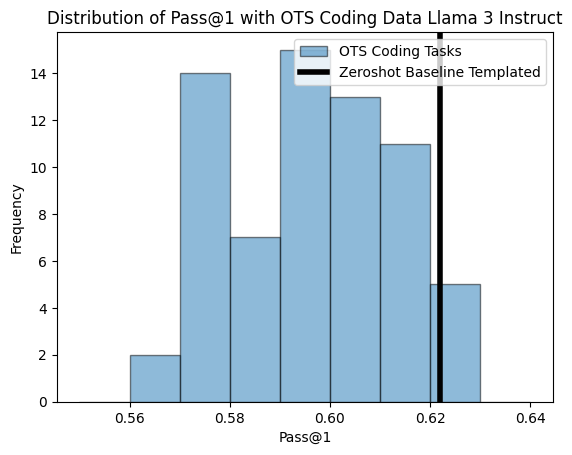

In [79]:
create_plot(llama3_good_ex, None, 'Llama 3 Instruct', "llama3_ots.png")

In [80]:
create_plot(code_llama_good_ex, None, 'Code Llama Instruct', "code_llama_ots.png")

Index(['One Shot Example Used', 'Pass@1', 'Net New Passes', 'Net New Fails'], dtype='object')
Error in callback <function flush_figures at 0x7ffa95336820> (for post_execute):


KeyboardInterrupt: 

In [ ]:
baseline = [1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0]
code_llama_ex163_bad = [1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0]

In [ ]:
new_right = [i for i in range(164) if baseline[i] == 0 and code_llama_ex163_bad[i] == 1]
new_right

[10, 14, 43, 116, 155]

## Analyze Generations Code Llama

In [ ]:
import json
with open("/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/synthetic_example_reruns_0807/code-llama-synthetic-examples/bad_examples/vllm_generation_results_zeroshot_baseline.json", "r") as f:
    baseline_data = json.load(f)

In [ ]:
import json
with open("/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/synthetic_example_reruns_0807/v3_prompt_template_rerun/code-llama-instruct/bad_examples/vllm_generation_results_163.json", "r") as f:
    data = json.load(f)

In [ ]:
print(baseline_data[155])
# This baseline is failing because of a setnence at the end (7. 28) (13, 14, 24, )


def even_odd_count(num):
    """Given an integer. return a tuple that has the number of even and odd digits respectively.

     Example:
        even_odd_count(-12) ==> (1, 1)
        even_odd_count(123) ==> (1, 2)
    """

    count_even = 0
    count_odd = 0
    for digit in str(abs(num)):
        if digit == '0':
            count_even += 1
        else:
            count_odd += 1
    return (count_even, count_odd)


In [ ]:
print(data[155])


def even_odd_count(num):
    """Given an integer. return a tuple that has the number of even and odd digits respectively.

     Example:
        even_odd_count(-12) ==> (1, 1)
        even_odd_count(123) ==> (1, 2)
    """

    count_even = 0
    count_odd = 0
    for digit in str(abs(num)):
        if int(digit) % 2 == 0:
            count_even += 1
        else:
            count_odd += 1
    return (count_even, count_odd)


# Llama 3 analyze generations

In [80]:
llama_3_baseline = [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0]
llama3_ex163_good = [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0] 
llama3_ex154_good = [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0]   
llama3_ex150_good = [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0]
llama3_ex162_good = [1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0]
llama3_ots36 = [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0] 
llama3_ots44 = [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0] 

In [82]:
new_wrong = [i for i in range(164) if llama_3_baseline[i] == 1 and llama3_ots44[i] == 0]
new_wrong

[11, 38, 46, 50, 67, 69, 73, 87, 153, 159]

In [83]:
import json
with open("/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/synthetic_example_reruns_0807/llama-3-instruct-synthetic-examples/vllm_generation_results_zeroshot_baseline_fixed_second.json", "r") as f:
    llama3_baseline_data = json.load(f)
with open("/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/ots_example_reruns_0810/llama-3-instruct-post-processed-new/vllm_generation_results_ots_nuggets_44.json.json", "r") as f:
    llama3_oneshot_data = json.load(f)


In [100]:
print(llama3_baseline_data[87])


def get_row(lst, x):
    """
    You are given a 2 dimensional data, as a nested lists,
    which is similar to matrix, however, unlike matrices,
    each row may contain a different number of columns.
    Given lst, and integer x, find integers x in the list,
    and return list of tuples, [(x1, y1), (x2, y2) ...] such that
    each tuple is a coordinate - (row, columns), starting with 0.
    Sort coordinates initially by rows in ascending order.
    Also, sort coordinates of the row by columns in descending order.
    
    Examples:
    get_row([
      [1,2,3,4,5,6],
      [1,2,3,4,1,6],
      [1,2,3,4,5,1]
    ], 1) == [(0, 0), (1, 4), (1, 0), (2, 5), (2, 0)]
    get_row([], 1) == []
    get_row([[], [1], [1, 2, 3]], 3) == [(2, 2)]
    """

    result = [(i, j) for i, row in enumerate(lst) for j, val in enumerate(row) if val == x]
    result.sort(key=lambda x: (x[0], -x[1]))
    return result


In [101]:
print(llama3_oneshot_data[87])


def get_row(lst, x):
    """
    You are given a 2 dimensional data, as a nested lists,
    which is similar to matrix, however, unlike matrices,
    each row may contain a different number of columns.
    Given lst, and integer x, find integers x in the list,
    and return list of tuples, [(x1, y1), (x2, y2) ...] such that
    each tuple is a coordinate - (row, columns), starting with 0.
    Sort coordinates initially by rows in ascending order.
    Also, sort coordinates of the row by columns in descending order.
    
    Examples:
    get_row([
      [1,2,3,4,5,6],
      [1,2,3,4,1,6],
      [1,2,3,4,5,1]
    ], 1) == [(0, 0), (1, 4), (1, 0), (2, 5), (2, 0)]
    get_row([], 1) == []
    get_row([[], [1], [1, 2, 3]], 3) == [(2, 2)]
    """

    result = []
    for i, row in enumerate(lst):
        if x in row:
            result.append((i, row.index(x)))
    result.sort(key=lambda x: (x[0], -x[1]))
    return result


# Trying to postprocess generations to remove english text at the end of generation that is causing unit tests to fail. 

In [2]:
import json
def post_process_generation(directory, file_name):
    with open(f'{directory}/{file_name}', 'r') as f:
        data = json.load(f)
    new_data = []
    for idx, ex in enumerate(data):
        last_return = ex.rfind("    return")
        last_newline = ex.rfind("\n")
        if last_newline > last_return:
            print(f"Changing {idx} task to")
            print("REMOVING")
            print(ex[last_newline:])
            # import pdb; pdb.set_trace()
            ex = ex[:last_newline]
        new_data.append(ex)
    with open(f'/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/debugging_large_dataset_rerun_v3prompt_0811_processed/{file_name}', 'w') as f:
        json.dump(new_data, f)

In [3]:
import os

directory = '/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/debugging_large_dataset_rerun_v3prompt_0811'

# post_process_generation(directory, "vllm_generation_results_ots_nuggets_36.json.json")

file_list = os.listdir(directory)

for file_name in file_list:
    file_path = os.path.join(directory, file_name)
    if os.path.isfile(file_path):
        post_process_generation(directory, file_name)

Changing 5 task to
REMOVING


Changing 25 task to
REMOVING


Changing 34 task to
REMOVING

This function works by first converting the list to a set, which automatically removes any duplicate elements. Then, it sorts the set and returns the result. The time complexity of this function is O(n log n) due to the sorting operation, where n is the number of elements in the list.
Changing 35 task to
REMOVING

This function uses Python's built-in max function to find the maximum element in the list. The max function returns the largest item in an iterable or the largest of two or more arguments.
Changing 39 task to
REMOVING


Changing 44 task to
REMOVING


Changing 50 task to
REMOVING


Changing 145 task to
REMOVING


Changing 5 task to
REMOVING


Changing 7 task to
REMOVING

This function uses a list comprehension to iterate over the input list of strings and checks if the substring is present in each string. If the substring is found, the string is included in the output list. If not, it is

In [66]:
with open(f"/mnt/efs/mehermankikar/bigcode-evaluation-harness/bigcode_eval/tasks/ots_example_reruns_0810/llama-3-instruct-post-processed-new/vllm_generation_results_ots_nuggets_36.json.json", "r") as f:
        data = json.load(f)
print(data[7])

from typing import List


def filter_by_substring(strings: List[str], substring: str) -> List[str]:
    """ Filter an input list of strings only for ones that contain given substring
    >>> filter_by_substring([], 'a')
    []
    >>> filter_by_substring(['abc', 'bacd', 'cde', 'array'], 'a')
    ['abc', 'bacd', 'array']
    """

    return [s for s in strings if substring in s]

